<a href="https://colab.research.google.com/github/javmencia/ReSTORELab/blob/main/SLElstmFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Model with all varaibles and full patient followups

/tmp/ipython-input-5-1032831624.py:15: DtypeWarning: Columns (7,94,95,139,148,155,157) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatanodead.csv', parse_dates=['ASSDT'])
/tmp/ipython-input-5-1032831624.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['end_state_encoded'] = LabelEncoder().fit_transform(data['end_state'])


=== Feature Selection with Random Forest ===

Selected Top 20 Features:
1. time_since_last (importance: 0.0153)
2. area (importance: 0.0154)
3. ID (importance: 0.0155)
4. total_visits (importance: 0.0158)
5. visit_num (importance: 0.0162)
6. visit_num96 (importance: 0.0170)
7. time_first_last (importance: 0.0178)
8. sick_leave_duration (importance: 0.0184)
9. cum_area (importance: 0.0188)
10. total_visits96 (importance: 0.0193)
11. sick_leave_spell (importance: 0.0201)
12. time_first_last96 (importance: 0.0202)
13. time_since_first (importance: 0.0210)
14. age_at_record (importance: 0.0243)
15. cum_time (importance: 0.0256)
16. time_to_first_change (importance: 0.0269)
17. age_at_retirement (importance: 0.0499)
18. early_retirement (importance: 0.0536)
19. first_change_index (importance: 0.0711)
20. EMP_numeric (importance: 0.1098)

=== Training LSTM with Selected Features ===

Fold 1/5
Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 292ms/step - accuracy: 0.3339 - loss: 1.9231 - val_accura

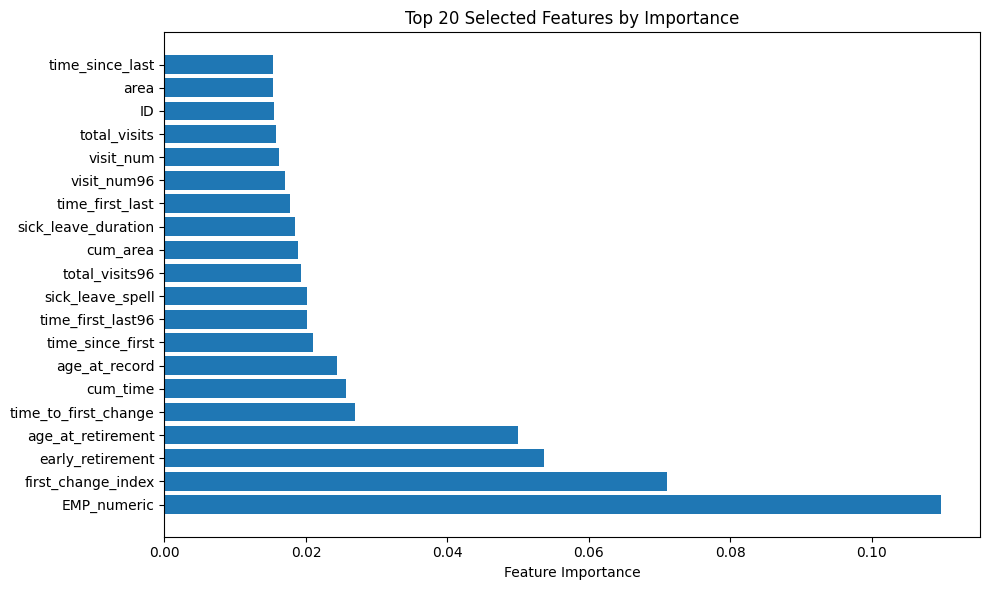

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# --- Data Loading and Preparation ---
data = pd.read_csv('sledatanodead.csv', parse_dates=['ASSDT'])

# Feature Engineering
data['sdi_flare_interaction'] = data['score_n'] * data['total_flares']
data['flares_per_month'] = data['total_flares'] / (data['time_since_first']/30 + 1e-6)
data['delta_SLEDAI_Renal'] = data.groupby('PTNO')['SLEDAI_Renal'].diff().fillna(0)

# Select features
numeric_cols = [col for col in data.select_dtypes(include=['int64', 'float64']).columns ]

# --- Data Cleaning and Scaling ---
for col in numeric_cols:
    # Handle infinite values
    data[col] = data[col].replace([np.inf, -np.inf], np.nan)

    # Log-transform large values
    if data[col].max() > 1e6:
        data[col] = np.log1p(data[col])

    # Fill NaNs
    data[col] = data[col].fillna(0)

# Apply scaling
scaler = MinMaxScaler(feature_range=(0, 1))
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
data['end_state_encoded'] = LabelEncoder().fit_transform(data['end_state'])

# --- Feature Selection with Random Forest ---
print("=== Feature Selection with Random Forest ===")

# Get MAXIMUM value for each patient (changed from last observation)
max_obs = data.groupby('PTNO')[numeric_cols].max()
y_labels = data.groupby('PTNO')['end_state_encoded'].last()  # Last outcome

# Train RF to get feature importances
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(max_obs, y_labels)

# Get top 20 features
importances = rf.feature_importances_
top_20_idx = np.argsort(importances)[-20:]
selected_features = [numeric_cols[i] for i in top_20_idx]

print("\nSelected Top 20 Features:")
for i, feat in enumerate(selected_features):
    print(f"{i+1}. {feat} (importance: {importances[top_20_idx][i]:.4f})")

# --- Prepare Sequences with Selected Features ---
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()

    X_seq = np.zeros((len(patients), max_seq_length, len(features)))
    y = np.zeros(len(patients))

    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        X_seq[i, :seq_len, :] = patient_data[features].values
        y[i] = patient_data['end_state_encoded'].iloc[-1]

    return X_seq, to_categorical(y)

# Create sequences with only selected features
X_seq, y = create_sequences(data, selected_features)
y_labels = np.argmax(y, axis=1)

# --- LSTM Model ---
def build_lstm_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Masking(mask_value=0)(inputs)
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(32)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    return model

# --- LSTM Training with Selected Features ---
print("\n=== Training LSTM with Selected Features ===")
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
lstm_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_seq, y_labels)):
    print(f"\nFold {fold + 1}/{n_splits}")

    X_train, X_val = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Train LSTM
    model = build_lstm_model((X_seq.shape[1], X_seq.shape[2]), y.shape[1])
    model.fit(X_train, y_train,
              epochs=150,
              batch_size=32,
              validation_data=(X_val, y_val),
              callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
              verbose=1)

    # Evaluate
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_val, axis=1)

    bal_acc = balanced_accuracy_score(y_true_classes, y_pred_classes)
    lstm_scores.append(bal_acc)

    print(f"\nFold {fold + 1} Balanced Accuracy: {bal_acc:.4f}")
    print(classification_report(y_true_classes, y_pred_classes))

# Final Results
print("\n=== Final Results ===")
print(f"Average Balanced Accuracy: {np.mean(lstm_scores):.4f} ± {np.std(lstm_scores):.4f}")
print(f"Selected Features Used: {selected_features}")

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(range(len(selected_features)), importances[top_20_idx][::-1])
plt.yticks(range(len(selected_features)), np.array(selected_features)[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Selected Features by Importance")
plt.tight_layout()
plt.show()

## Model with full patient followups but no data leak

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import random
import tensorflow as tf

# --- Data Loading and Preparation ---
data = pd.read_csv('sledatacut2.csv', parse_dates=['ASSDT'])

random.seed(1927)
np.random.seed(1927)
tf.random.set_seed(1927)
# Feature Engineering
data['sdi_flare_interaction'] = data['score_n'] * data['total_flares']
data['flares_per_month'] = data['total_flares'] / (data['time_since_first']/30 + 1e-6)
data['delta_SLEDAI_Renal'] = data.groupby('PTNO')['SLEDAI_Renal'].diff().fillna(0)

# Select features
numeric_cols = [col for col in data.select_dtypes(include=['int64', 'float64']).columns ]

# --- Data Cleaning and Scaling ---
for col in numeric_cols:
    # Handle infinite values
    data[col] = data[col].replace([np.inf, -np.inf], np.nan)

    # Log-transform large values
    if data[col].max() > 1e6:
        data[col] = np.log1p(data[col])

    # Fill NaNs
    data[col] = data[col].fillna(0)

# Apply scaling
scaler = MinMaxScaler(feature_range=(0, 1))
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
data['end_state_encoded'] = LabelEncoder().fit_transform(data['end_state'])

# --- Feature Selection with Random Forest ---
print("=== Feature Selection with Random Forest ===")

# Get MAXIMUM value for each patient (changed from last observation)
max_obs = data.groupby('PTNO')[numeric_cols].max()
y_labels = data.groupby('PTNO')['end_state_encoded'].last()  # Last outcome

# Train RF to get feature importances
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(max_obs, y_labels)

# Get top 20 features
importances = rf.feature_importances_
top_20_idx = np.argsort(importances)[-20:]
selected_features = [numeric_cols[i] for i in top_20_idx]

print("\nSelected Top 20 Features:")
for i, feat in enumerate(selected_features):
    print(f"{i+1}. {feat} (importance: {importances[top_20_idx][i]:.4f})")

# --- Prepare Sequences with Selected Features ---
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()

    X_seq = np.zeros((len(patients), max_seq_length, len(features)))
    y = np.zeros(len(patients))

    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        X_seq[i, :seq_len, :] = patient_data[features].values
        y[i] = patient_data['end_state_encoded'].iloc[-1]

    return X_seq, to_categorical(y)

# Create sequences with only selected features
X_seq, y = create_sequences(data, selected_features)
y_labels = np.argmax(y, axis=1)

# --- LSTM Model ---
def build_lstm_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Masking(mask_value=0)(inputs)
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(32)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    return model

# --- LSTM Training with Selected Features ---
print("\n=== Training LSTM with Selected Features ===")
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
lstm_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_seq, y_labels)):
    print(f"\nFold {fold + 1}/{n_splits}")

    X_train, X_val = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Train LSTM
    model = build_lstm_model((X_seq.shape[1], X_seq.shape[2]), y.shape[1])
    model.fit(X_train, y_train,
              epochs=150,
              batch_size=32,
              validation_data=(X_val, y_val),
              callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
              verbose=1)

    # Evaluate
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_val, axis=1)

    bal_acc = balanced_accuracy_score(y_true_classes, y_pred_classes)
    lstm_scores.append(bal_acc)

    print(f"\nFold {fold + 1} Balanced Accuracy: {bal_acc:.4f}")
    print(classification_report(y_true_classes, y_pred_classes))

# Final Results
print("\n=== Final Results ===")
print(f"Average Balanced Accuracy: {np.mean(lstm_scores):.4f} ± {np.std(lstm_scores):.4f}")
print(f"Selected Features Used: {selected_features}")

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(range(len(selected_features)), importances[top_20_idx][::-1])
plt.yticks(range(len(selected_features)), np.array(selected_features)[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Selected Features by Importance")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3-1030849930.py:17: DtypeWarning: Columns (136,138,145,147,154,156,161) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('sledatacut2.csv', parse_dates=['ASSDT'])
/tmp/ipython-input-3-1030849930.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['end_state_encoded'] = LabelEncoder().fit_transform(data['end_state'])


=== Feature Selection with Random Forest ===

Selected Top 20 Features:
1. cum_area (importance: 0.0149)
2. time_between (importance: 0.0149)
3. PTNO (importance: 0.0150)
4. time_between96 (importance: 0.0157)
5. ID (importance: 0.0171)
6. sick_leave_duration (importance: 0.0180)
7. total_visits96 (importance: 0.0185)
8. total_visits (importance: 0.0197)
9. sick_leave_spell (importance: 0.0198)
10. time_first_last (importance: 0.0238)
11. time_first_last96 (importance: 0.0240)
12. visit_num (importance: 0.0240)
13. time_to_first_change (importance: 0.0263)
14. cum_time (importance: 0.0266)
15. time_since_first (importance: 0.0272)
16. age_at_record (importance: 0.0294)
17. visit_num96 (importance: 0.0482)
18. age_at_retirement (importance: 0.0510)
19. early_retirement (importance: 0.0706)
20. EMP_numeric (importance: 0.1201)

=== Training LSTM with Selected Features ===

Fold 1/5
Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 294ms/step - accuracy: 0.4897 - loss: 1.7353 - val_accuracy: 0.1

## Model that only looks at employment portion of patients

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, balanced_accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Masking, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import random
import tensorflow as tf

# --- Data Loading and Preparation ---
data = pd.read_csv('sledatacut2.csv', parse_dates=['ASSDT'])
random.seed(1927)
np.random.seed(1927)
tf.random.set_seed(1927)

# Feature Engineering
data['sdi_flare_interaction'] = data['score_n'] * data['total_flares']
data['flares_per_month'] = data['total_flares'] / (data['time_since_first']/30 + 1e-6)
data['delta_SLEDAI_Renal'] = data.groupby('PTNO')['SLEDAI_Renal'].diff().fillna(0)

# Select features
numeric_cols = [col for col in data.select_dtypes(include=['int64', 'float64']).columns
               if col not in ['PTNO', 'end_state_encoded', 'first_change_index', 'time_since_first', 'time_since_last', 'ID', 'MAXSTEROIDDOSE', 'time_between96', 'early_retirement', 'DEATH', 'age_at_death', 'age_at_retirement', 'EMP_numeric', 'lupus_primary_death', 'visit_num96', 'lupus_secondary_death', 'time_to_first_change']]


# --- Data Cleaning and Scaling ---
for col in numeric_cols:
    # Handle infinite values
    data[col] = data[col].replace([np.inf, -np.inf], np.nan)

    # Log-transform large values
    if data[col].max() > 1e6:
        data[col] = np.log1p(data[col])

    # Fill NaNs
    data[col] = data[col].fillna(0)

# Apply scaling
scaler = MinMaxScaler(feature_range=(0, 1))
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
data['end_state_encoded'] = LabelEncoder().fit_transform(data['end_state'])

# --- Feature Selection with Random Forest ---
print("=== Feature Selection with Random Forest ===")

# Get MAXIMUM value for each patient (changed from last observation)
max_obs = data.groupby('PTNO')[numeric_cols].max()
y_labels = data.groupby('PTNO')['end_state_encoded'].last()  # Last outcome

# Train RF to get feature importances
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(max_obs, y_labels)

# Get top 20 features
importances = rf.feature_importances_
top_20_idx = np.argsort(importances)[-20:]
selected_features = [numeric_cols[i] for i in top_20_idx]

print("\nSelected Top 20 Features:")
for i, feat in enumerate(selected_features):
    print(f"{i+1}. {feat} (importance: {importances[top_20_idx][i]:.4f})")

# --- Prepare Sequences with Selected Features ---
def create_sequences(data, features, max_seq_length=None):
    patients = data['PTNO'].unique()
    if not max_seq_length:
        max_seq_length = data.groupby('PTNO').size().max()

    X_seq = np.zeros((len(patients), max_seq_length, len(features)))
    y = np.zeros(len(patients))

    for i, patient in enumerate(patients):
        patient_data = data[data['PTNO'] == patient].sort_values('ASSDT')
        seq_len = len(patient_data)
        X_seq[i, :seq_len, :] = patient_data[features].values
        y[i] = patient_data['end_state_encoded'].iloc[-1]

    return X_seq, to_categorical(y)

# Create sequences with only selected features
X_seq, y = create_sequences(data, selected_features)
y_labels = np.argmax(y, axis=1)

# --- LSTM Model ---
def build_lstm_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Masking(mask_value=0)(inputs)
    x = LSTM(64, return_sequences=True)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(32)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    return model

# --- LSTM Training with Selected Features ---
print("\n=== Training LSTM with Selected Features ===")
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
lstm_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_seq, y_labels)):
    print(f"\nFold {fold + 1}/{n_splits}")

    X_train, X_val = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Train LSTM
    model = build_lstm_model((X_seq.shape[1], X_seq.shape[2]), y.shape[1])
    model.fit(X_train, y_train,
              epochs=150,
              batch_size=32,
              validation_data=(X_val, y_val),
              callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
              verbose=1)

    # Evaluate
    y_pred = model.predict(X_val)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true_classes = np.argmax(y_val, axis=1)

    bal_acc = balanced_accuracy_score(y_true_classes, y_pred_classes)
    lstm_scores.append(bal_acc)

    print(f"\nFold {fold + 1} Balanced Accuracy: {bal_acc:.4f}")
    print(classification_report(y_true_classes, y_pred_classes))

# Final Results
print("\n=== Final Results ===")
print(f"Average Balanced Accuracy: {np.mean(lstm_scores):.4f} ± {np.std(lstm_scores):.4f}")
print(f"Selected Features Used: {selected_features}")

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(range(len(selected_features)), importances[top_20_idx][::-1])
plt.yticks(range(len(selected_features)), np.array(selected_features)[::-1])
plt.xlabel("Feature Importance")
plt.title("Top 20 Selected Features by Importance")
plt.tight_layout()
plt.show()